# Tennis Match Winner Prediction with CatBoost

## Goal

The task is a **binary classification problem**:

- class `1`: player A wins;
- class `0`: player B wins.

The objective is to train a CatBoost classifier and evaluate whether it can
generalize to matches played after those used for training.

## Why CatBoost?

CatBoost is an **ensemble method based on boosting**. As discussed for
AdaBoost, boosting combines several decision trees sequentially: every new
tree tries to reduce the errors made by the current ensemble.

The final prediction is obtained by combining the contribution of all trees.
CatBoost is useful here because the dataset contains both numerical and
categorical attributes, such as surface, court and tournament.

## Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score,
)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "scripts" / "models"
sys.path.insert(0, str(MODELS_DIR))

from train_catboost import prepare_catboost_features
from training_utils import chronological_holdout_split

FEATURES_PATH = PROJECT_ROOT / "data/interim/tennis_matches_features.data"
METADATA_PATH = PROJECT_ROOT / "data/interim/tennis_matches_features_metadata.json"
METRICS_PATH = PROJECT_ROOT / "data/interim/catboost_metrics.json"

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Load the dataset

In [2]:
dataset = pd.read_csv(FEATURES_PATH)
dataset["date"] = pd.to_datetime(dataset["date"], errors="raise")

metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
training_metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))

columns_to_show = [
    "date",
    "surface",
    "winner_rank",
    "loser_rank",
    "rank_diff",
    "win_rate_diff",
    "implied_prob_diff_avg",
    "player_a_win",
]

print("Dataset shape:", dataset.shape)
display(dataset[columns_to_show].head())
display(dataset["player_a_win"].value_counts().sort_index().rename("instances").to_frame())

Dataset shape: (56450, 102)


,date,surface,winner_rank,loser_rank,rank_diff,win_rate_diff,implied_prob_diff_avg,player_a_win
0,2015-01-05,Hard,72.0,31.0,-41.0,NaN,-0.454545,0
1,2015-01-05,Hard,31.0,72.0,41.0,NaN,0.454545,1
2,2015-01-05,Hard,21.0,125.0,104.0,NaN,0.601315,0
3,2015-01-05,Hard,125.0,21.0,-104.0,NaN,-0.601315,1
4,2015-01-05,Hard,25.0,149.0,124.0,NaN,0.298593,0


,instances
player_a_win,
0,28225
1,28225


The dataset contains two rows for every real match: one for each
player orientation. This produces a balanced target and avoids making the
model depend on the original winner/loser column order.

Only pre-match information is used: rankings, previous results, surface form,
head-to-head history, player statistics and market probabilities.

## 2. Prepare features and create the train/test split

A random split is not appropriate for this problem because it could
train the model on future matches and test it on older matches.

The most recent 15% of unique dates is therefore used as the **test set**. The
remaining older matches form the **training set**. Both orientations of a
match have the same date and remain in the same partition.

In [3]:
numeric_features = tuple(metadata["numeric_features"])
categorical_features = tuple(metadata["categorical_features"])
feature_names = numeric_features + categorical_features

X = prepare_catboost_features(
    dataset.loc[:, feature_names],
    numeric_features,
    categorical_features,
)
y = dataset["player_a_win"].astype(int)

train_index, test_index = chronological_holdout_split(dataset["date"], 0.15)
X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]

split = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "first date": [
            dataset.iloc[train_index]["date"].min().date(),
            dataset.iloc[test_index]["date"].min().date(),
        ],
        "last date": [
            dataset.iloc[train_index]["date"].max().date(),
            dataset.iloc[test_index]["date"].max().date(),
        ],
    },
    index=["training", "test"],
)
display(split)

,rows,first date,last date
training,48158,2015-01-05,2024-11-14
test,8292,2024-11-15,2026-07-19


## 3. Naive baseline

A classifier must be compared with a simple baseline. Following the
course notes, the naive classifier always predicts the majority class.

Because the symmetric dataset is balanced, the expected baseline accuracy is
approximately 50%.

In [4]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_accuracy = accuracy_score(y_test, baseline.predict(X_test))

print(f"Naive baseline accuracy: {baseline_accuracy:.4f}")

Naive baseline accuracy: 0.5000


## 4. Hyper-parameter tuning

The parameters were selected with `GridSearchCV`, as in the course
example. Every parameter combination was evaluated using five chronological
cross-validation folds. The final test set was not used during this selection.

The grid controls:

- `iterations`: number of trees in the ensemble;
- `depth`: maximum depth of every tree;
- `learning_rate`: contribution of each new tree;
- `l2_leaf_reg`: regularization used to limit over-fitting.

In [5]:
print("Parameter grid:")
display(pd.Series(training_metrics["parameter_grid"], name="tested values").to_frame())

print(f"Best cross-validation accuracy: {training_metrics['best_cv_accuracy']:.4f}")
print("Best parameters:", training_metrics["best_params"])

Parameter grid:


,tested values
iterations,"[300, 600]"
depth,"[4, 6, 8]"
learning_rate,"[0.03, 0.1]"
l2_leaf_reg,"[3.0, 7.0]"


Best cross-validation accuracy: 0.6838
Best parameters: {'depth': 8, 'iterations': 300, 'l2_leaf_reg': 3.0, 'learning_rate': 0.03}


## 5. Train the final model

In [6]:
model = CatBoostClassifier(
    **training_metrics["best_params"],
    loss_function="Logloss",
    eval_metric="Accuracy",
    cat_features=categorical_features,
    random_seed=42,
    allow_writing_files=False,
    verbose=False,
    thread_count=1,
)

model.fit(X_train, y_train)
print("Training completed.")

Training completed.


## 6. Evaluate the classifier

In [7]:
train_prediction = model.predict(X_train).astype(int).ravel()
test_prediction = model.predict(X_test).astype(int).ravel()
test_probability = model.predict_proba(X_test)[:, 1]

train_accuracy = accuracy_score(y_train, train_prediction)
test_accuracy = accuracy_score(y_test, test_prediction)
test_auc = roc_auc_score(y_test, test_probability)

results = pd.Series(
    {
        "Naive baseline accuracy": baseline_accuracy,
        "Training accuracy": train_accuracy,
        "Cross-validation accuracy": training_metrics["best_cv_accuracy"],
        "Test accuracy": test_accuracy,
        "Test ROC AUC": test_auc,
    },
    name="score",
)
display(results.to_frame())

,score
Naive baseline accuracy,0.500000
Training accuracy,0.709539
Cross-validation accuracy,0.683809
Test accuracy,0.683792
Test ROC AUC,0.752827


### Confusion matrix

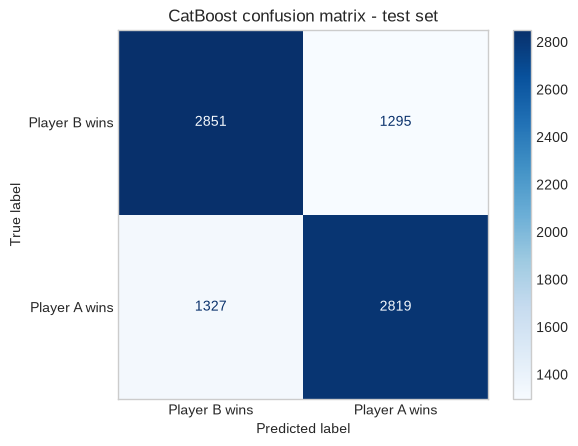

In [8]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    display_labels=["Player B wins", "Player A wins"],
    cmap="Blues",
)
plt.title("CatBoost confusion matrix - test set")
plt.grid(False)
plt.show()

### Precision, recall and F1-score

In [9]:
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=["Player B wins", "Player A wins"],
        digits=4,
    )
)

               precision    recall  f1-score   support

Player B wins     0.6824    0.6877    0.6850      4146
Player A wins     0.6852    0.6799    0.6826      4146

     accuracy                         0.6838      8292
    macro avg     0.6838    0.6838    0.6838      8292
 weighted avg     0.6838    0.6838    0.6838      8292



### ROC curve

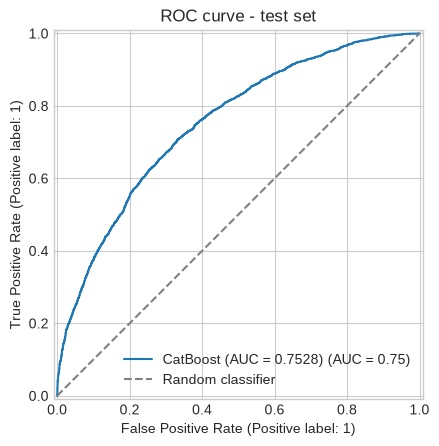

In [10]:
RocCurveDisplay.from_predictions(
    y_test,
    test_probability,
    name=f"CatBoost (AUC = {test_auc:.4f})",
)
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random classifier")
plt.title("ROC curve - test set")
plt.legend()
plt.show()

## 7. Feature importance

Tree-based models expose a feature-importance score. The score
indicates how much each feature contributes to the decisions of the ensemble.
As discussed in the course, importance is useful for interpretation, but it
does not prove that a feature causes the prediction.

,importance
winner_implied_prob_avg,14.894660
loser_implied_prob_avg,11.411967
implied_prob_diff_avg,9.319226
loser_days_since_last_match,2.838682
winner_days_since_last_match,2.627039
winner_age_years,2.171794
tournament_bucket,1.993726
loser_age_years,1.961051
win_rate_diff,1.603300
location_bucket,1.431928


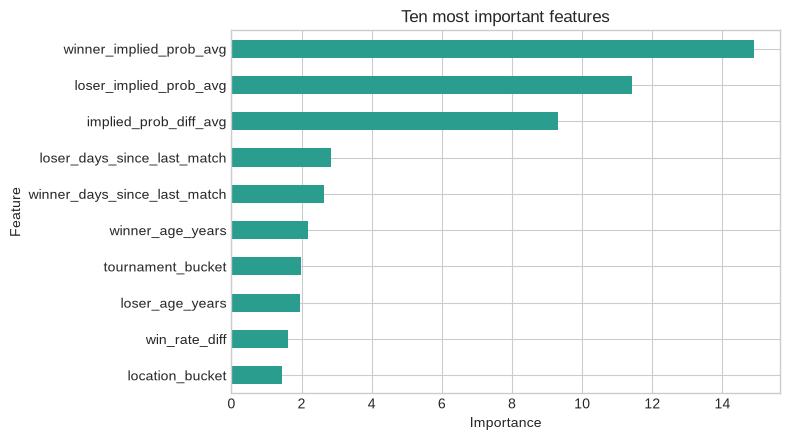

In [11]:
feature_importance = (
    pd.Series(
        np.asarray(model.feature_importances_, dtype=float),
        index=feature_names,
        name="importance",
    )
    .sort_values(ascending=False)
    .head(10)
)

display(feature_importance.to_frame())

ax = feature_importance.sort_values().plot(
    kind="barh",
    figsize=(8, 4.5),
    color="#2a9d8f",
)
ax.set_title("Ten most important features")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## Conclusion

- The naive baseline obtains about **50% accuracy** because the classes are
  balanced.
- CatBoost obtains **0.6838 cross-validation accuracy** and
  **0.6838 test accuracy**, so the result is stable on future
  matches.
- The model improves clearly over the naive baseline.
- Market-implied probabilities are the most important features. Therefore,
  part of the predictive power comes from information already contained in
  betting odds.
- The difference between training and test accuracy should be monitored: a
  much larger training score would indicate over-fitting.

The final test set is used only once for evaluation. Any future change to the
features or CatBoost parameters must be selected using the training
cross-validation folds, not this test result.